# 10. Hard Case Mining y Sampling Refinado Thoracolumbar - Colab

Este notebook no cambia la estrategia general del proyecto. Su papel es preparar
mejor la siguiente iteracion del entrenamiento manteniendo el mismo pipeline:

1. localizacion binaria de columna
2. segmentacion multiclase thoracolumbar
3. estimador de ultima vertebra visible
4. clipping anatomico

## Por que existe este notebook

El informe de avance y la bitacora muestran que el cuello de botella real ya no
es encontrar la columna, sino manejar mejor:

- radiografias parciales
- desbalance de clases
- sobreprediccion en la ultima vertebra visible
- casos dificiles de escoliosis

## Objetivo

Construir insumos para una version mas fuerte del pipeline sin romper la
arquitectura actual:

- identificar slices dificiles del dataset
- medir rareza por vertebra y por ultima vertebra visible
- generar pesos refinados de muestreo para `multiclass` y `last_visible`
- exportar listas de casos prioritarios para revision y entrenamiento dirigido

## 0. Preparacion de Colab

Ajusta `PROJECT_ROOT` segun la ubicacion real de la carpeta en tu Google Drive.

In [1]:
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception as exc:
    print('No se detecto entorno Colab o Drive ya estaba montado:', exc)

# Cambia esta ruta solo si la carpeta del proyecto esta en otro lugar de tu Drive.
PROJECT_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'No existe la carpeta: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work


## 1. Librerias y resolucion de rutas

Este notebook puede funcionar tanto si tus salidas estan en `analysis_outputs/`
como si quedaron dentro de `reports/analysis_outputs/`.

In [2]:
from __future__ import annotations

import json
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'hard_case_mining_thoracolumbar_explained_tuned'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_existing(*relative_candidates: str) -> Path:
    search_roots = [ROOT, ROOT / 'data' / 'ScoliosisDataSetYeisson', ROOT / 'data', ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'No se encontro ninguno de estos archivos: {relative_candidates}')


def resolve_optional(*relative_candidates: str) -> Path | None:
    search_roots = [ROOT, ROOT / 'data' / 'ScoliosisDataSetYeisson', ROOT / 'data', ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    return None


MANIFEST_PATH = resolve_existing('analysis_outputs/training_manifest_thoracolumbar.csv')
PARTITION_SOURCE_PATH = resolve_optional(
    'analysis_outputs/training_runs/thoracolumbar_core_split_80_20.csv',
    'analysis_outputs/training_runs_cascade/thoracolumbar_core_split_train_val_test.csv',
    'analysis_outputs/training_runs/binary_spine_split_80_20.csv',
    'analysis_outputs/training_runs_cascade/binary_spine_split_train_val_test.csv',
)
LAST_COMPARE_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_per_sample_compare.csv'
)
LAST_TEST_PRED_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_test_predictions.csv'
)
LAST_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_experiment_summary.csv'
)
INFERENCE_PER_SAMPLE_PATH = resolve_existing(
    'analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_per_sample_summary.csv'
)
POST_V2_COMPARE_PATH = resolve_existing(
    'analysis_outputs/thoracolumbar_postprocess_anatomical_v2_explained_tuned/postprocess_v2_per_sample_compare.csv'
)

print('MANIFEST_PATH:', MANIFEST_PATH)
print('PARTITION_SOURCE_PATH:', PARTITION_SOURCE_PATH)
print('LAST_COMPARE_PATH:', LAST_COMPARE_PATH)
print('LAST_TEST_PRED_PATH:', LAST_TEST_PRED_PATH)
print('LAST_SUMMARY_PATH:', LAST_SUMMARY_PATH)
print('INFERENCE_PER_SAMPLE_PATH:', INFERENCE_PER_SAMPLE_PATH)
print('POST_V2_COMPARE_PATH:', POST_V2_COMPARE_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)


MANIFEST_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/reports/analysis_outputs/training_manifest_thoracolumbar.csv
PARTITION_SOURCE_PATH: None
LAST_COMPARE_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_per_sample_compare.csv
LAST_TEST_PRED_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_test_predictions.csv
LAST_SUMMARY_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_experiment_summary.csv
INFERENCE_PER_SAMPLE_PATH: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/thoracolumbar_inference_analysis_explained_tuned/inference_per_sample_summary.csv
POST_V2_CO

## 2. Carga de tablas base

Reunimos:

- manifiesto thoracolumbar
- errores por muestra del estimador `last_visible`
- resumen por muestra del multiclase crudo
- comparacion por muestra del postproceso `v2`

In [3]:
manifest_df = pd.read_csv(MANIFEST_PATH)
last_compare_df = pd.read_csv(LAST_COMPARE_PATH)
last_test_pred_df = pd.read_csv(LAST_TEST_PRED_PATH)
last_summary_df = pd.read_csv(LAST_SUMMARY_PATH)
inference_per_sample_df = pd.read_csv(INFERENCE_PER_SAMPLE_PATH)
post_v2_compare_df = pd.read_csv(POST_V2_COMPARE_PATH)

present_cols = [
    col for col in manifest_df.columns
    if col.startswith('present_') and col.replace('present_', '')[:1] in {'T', 'L'}
]

if 'partition' not in manifest_df.columns:
    if PARTITION_SOURCE_PATH is not None:
        partition_source_df = pd.read_csv(PARTITION_SOURCE_PATH)
        merge_cols = [col for col in ['unique_sample_id', 'partition'] if col in partition_source_df.columns]
        if {'unique_sample_id', 'partition'}.issubset(merge_cols):
            manifest_df = manifest_df.merge(
                partition_source_df[['unique_sample_id', 'partition']].drop_duplicates(),
                on='unique_sample_id',
                how='left',
            )

    if 'partition' not in manifest_df.columns or manifest_df['partition'].isna().all():
        if 'group_id_for_split' not in manifest_df.columns:
            raise KeyError(
                "No se encontro columna 'partition' ni 'group_id_for_split' para reconstruir la particion."
            )

        def deterministic_partition(group_id: object) -> str:
            digest = hashlib.md5(str(group_id).encode('utf-8')).hexdigest()
            bucket = int(digest[:8], 16) % 10
            return 'test' if bucket < 2 else 'train'

        manifest_df['partition'] = manifest_df['group_id_for_split'].apply(deterministic_partition)

manifest_df['partition'] = manifest_df['partition'].fillna('').astype(str).str.lower()

manifest_df['is_partial_case'] = manifest_df['num_visible_target_vertebrae'] < 17
manifest_df['is_scoliosis_case'] = manifest_df['split'].astype(str).str.lower().eq('scoliosis')
manifest_df['last_visible_target'] = manifest_df['last_visible_target'].fillna('')

subset_df = manifest_df.loc[
    manifest_df['usable_for_thoracolumbar_partial'].astype(str).str.lower().eq('true')
    | (manifest_df['usable_for_thoracolumbar_partial'] == True)
].copy()

print('manifest_df:', manifest_df.shape)
print('subset_df usable_for_thoracolumbar_partial:', subset_df.shape)
print('last_compare_df:', last_compare_df.shape)
print('last_test_pred_df:', last_test_pred_df.shape)
print('inference_per_sample_df:', inference_per_sample_df.shape)
print('post_v2_compare_df:', post_v2_compare_df.shape)
display(last_summary_df)

manifest_df: (250, 55)
subset_df usable_for_thoracolumbar_partial: (224, 55)
last_compare_df: (45, 21)
last_test_pred_df: (45, 12)
inference_per_sample_df: (45, 15)
post_v2_compare_df: (45, 14)


,metric,value
0,target_subset,partial
1,test_samples,45
2,last_test_exact_acc,0.4222222222222222
3,last_test_within1_acc,0.5777777777777777
4,last_test_mae,2.0
5,last_test_overprediction_rate,0.4
6,raw_macro_dice_fg,0.33989113009940214
7,oracle_macro_dice_fg,0.3711096762114791
8,last_pred_clip_macro_dice_fg,0.3519338546532042
9,mean_raw_extra_count,3.0444444444444443


## 3. Desbalance anatomico en train

Esta seccion responde una pregunta practica:

> Que vertebras y que etiquetas de `last_visible_target` estan menos cubiertas en
> entrenamiento y por tanto deberian pesar mas en el sampler?

In [4]:
train_subset_df = subset_df.loc[
    subset_df['needs_annotation_review'].astype(str).str.lower().ne('true')
    & (subset_df['partition'] == 'train')
].copy()

presence_rows = []
for col in present_cols:
    label = col.replace('present_', '')
    count = int(pd.to_numeric(train_subset_df[col], errors='coerce').fillna(0).sum())
    presence_rows.append({'vertebra_label': label, 'train_images_with_label': count})

vertebra_presence_train_df = pd.DataFrame(presence_rows).sort_values(
    'train_images_with_label', ascending=True
).reset_index(drop=True)
vertebra_presence_train_df['coverage_ratio'] = (
    vertebra_presence_train_df['train_images_with_label'] / max(len(train_subset_df), 1)
)
vertebra_presence_train_df['rarity_weight'] = (
    vertebra_presence_train_df['train_images_with_label'].max()
    / vertebra_presence_train_df['train_images_with_label'].clip(lower=1)
) ** 0.5

last_visible_distribution_df = (
    train_subset_df.groupby('last_visible_target')
    .size()
    .rename('train_images')
    .reset_index()
    .sort_values('train_images', ascending=True)
    .reset_index(drop=True)
)
last_visible_distribution_df['coverage_ratio'] = (
    last_visible_distribution_df['train_images'] / max(len(train_subset_df), 1)
)
last_visible_distribution_df['rarity_weight'] = (
    last_visible_distribution_df['train_images'].max()
    / last_visible_distribution_df['train_images'].clip(lower=1)
) ** 0.5

display(vertebra_presence_train_df)
display(last_visible_distribution_df)

,vertebra_label,train_images_with_label,coverage_ratio,rarity_weight
0,L5,63,0.338710,1.718249
1,L4,86,0.462366,1.470643
2,L3,108,0.580645,1.312335
3,L2,122,0.655914,1.234743
4,L1,129,0.693548,1.200775
5,T12,144,0.774194,1.136515
6,T11,158,0.849462,1.084995
7,T10,174,0.935484,1.033908
8,T9,176,0.946237,1.028017
9,T1,177,0.951613,1.025109


,last_visible_target,train_images,coverage_ratio,rarity_weight
0,T9,2,0.010753,5.612486
1,T7,2,0.010753,5.612486
2,T6,3,0.016129,4.582576
3,T8,5,0.026882,3.549648
4,L1,8,0.043011,2.806243
5,L2,14,0.075269,2.121320
6,T11,14,0.075269,2.121320
7,T12,14,0.075269,2.121320
8,T10,16,0.086022,1.984313
9,L3,22,0.118280,1.692228


## 4. Union de slices dificiles en test

Aqui conectamos anatomia y errores reales del pipeline actual.

Esto nos permite responder:

- En que tipos de muestra se concentra la sobreprediccion.
- Si los casos parciales y de escoliosis siguen siendo los mas dificiles.
- Si hay targets de `last_visible` especialmente fragiles.

In [5]:
def coalesce_column(df: pd.DataFrame, preferred: str, candidates: list[str]) -> pd.DataFrame:
    available = [col for col in candidates if col in df.columns]
    if preferred in df.columns and preferred not in available:
        available = [preferred] + available
    if not available:
        return df

    series = df[available[0]].copy()
    for col in available[1:]:
        series = series.fillna(df[col])

    df[preferred] = series
    return df


analysis_df = (
    last_compare_df
    .merge(last_test_pred_df, on='unique_sample_id', how='left', suffixes=('', '_pred'))
    .merge(
        inference_per_sample_df[
            ['unique_sample_id', 'roi_source', 'num_gt_labels', 'num_pred_labels', 'num_missing_labels', 'num_extra_labels']
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        post_v2_compare_df[
            ['unique_sample_id', 'post_missing_count', 'post_extra_count', 'extra_reduction', 'missing_change']
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        manifest_df[
            [
                'unique_sample_id', 'split', 'image', 'num_visible_target_vertebrae', 'last_visible_target',
                'total_internal_missing_count', 'has_thoracic', 'has_lumbar'
            ]
        ].rename(columns={'split': 'manifest_split', 'image': 'manifest_image'}),
        on='unique_sample_id',
        how='left',
    )
)

analysis_df = coalesce_column(analysis_df, 'split', ['split', 'split_x', 'split_y', 'manifest_split'])
analysis_df = coalesce_column(analysis_df, 'image', ['image', 'image_x', 'image_y', 'manifest_image'])

if 'split' not in analysis_df.columns:
    raise KeyError(
        f"No fue posible reconstruir la columna 'split'. Columnas disponibles: {sorted(analysis_df.columns.tolist())}"
    )

if 'image' not in analysis_df.columns:
    raise KeyError(
        f"No fue posible reconstruir la columna 'image'. Columnas disponibles: {sorted(analysis_df.columns.tolist())}"
    )

analysis_df['is_partial_case'] = analysis_df['num_visible_target_vertebrae'] < 17
analysis_df['is_scoliosis_case'] = analysis_df['split'].astype(str).str.lower().eq('scoliosis')
analysis_df['is_overprediction_case'] = analysis_df['last_overprediction'].fillna(False)
analysis_df['is_underprediction_case'] = analysis_df['last_underprediction'].fillna(False)
analysis_df['benefited_from_last_clip'] = (
    (analysis_df['last_extra_reduction_vs_raw'] > 0)
    & (analysis_df['last_missing_change_vs_raw'] <= 0)
)
analysis_df['harm_from_last_clip'] = analysis_df['last_missing_change_vs_raw'] > 0

display(analysis_df.head())


,unique_sample_id,split,image,gt_first_label,gt_last_label,last_pred_label,gt_labels,raw_labels,oracle_labels,last_pred_clip_labels,...,last_visible_target,total_internal_missing_count,has_thoracic,has_lumbar,is_partial_case,is_scoliosis_case,is_overprediction_case,is_underprediction_case,benefited_from_last_clip,harm_from_last_clip
0,Normal__N_4.jpg,Normal,N_4.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,L5,0,True,True,False,False,False,False,False,False
1,Normal__N_6.jpg,Normal,N_6.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,L5,0,True,True,False,False,False,False,False,False
2,Normal__N_8.jpg,Normal,N_8.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,L5,0,True,True,False,False,False,False,False,False
3,Normal__N_15.jpg,Normal,N_15.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,L5,0,True,True,False,False,False,False,False,False
4,Normal__N_18.jpg,Normal,N_18.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,L5,0,True,True,False,False,False,False,False,False


## 5. Lectura por slices

Agrupamos por caracteristicas clave para detectar donde realmente conviene hacer
mas enfasis de entrenamiento.

In [6]:
slice_rows = []
slice_specs = [
    ('all_test', pd.Series([True] * len(analysis_df))),
    ('partial', analysis_df['is_partial_case']),
    ('full_range', ~analysis_df['is_partial_case']),
    ('scoliosis', analysis_df['is_scoliosis_case']),
    ('normal', ~analysis_df['is_scoliosis_case']),
    ('internal_missing_gt', analysis_df['total_internal_missing_count'].fillna(0) > 0),
    ('lumbar_visible_gt', analysis_df['last_true_idx'].fillna(-1) >= 12),
    ('thoracic_end_gt', analysis_df['last_true_idx'].fillna(-1) < 12),
]

for slice_name, mask in slice_specs:
    work = analysis_df.loc[mask.fillna(False)].copy()
    if work.empty:
        continue
    slice_rows.append({
        'slice_name': slice_name,
        'images': len(work),
        'exact_acc': float(work['last_exact_match'].mean()),
        'within1_acc': float(work['last_within1_match'].mean()),
        'mae': float(work['last_abs_error'].mean()),
        'overprediction_rate': float(work['last_overprediction'].mean()),
        'mean_raw_extra_count': float(work['raw_extra_count'].mean()),
        'mean_last_extra_count': float(work['last_extra_count'].mean()),
        'mean_last_missing_count': float(work['last_missing_count'].mean()),
        'clean_improvement_rate': float(work['benefited_from_last_clip'].mean()),
        'harm_rate': float(work['harm_from_last_clip'].mean()),
    })

slice_summary_df = pd.DataFrame(slice_rows).sort_values(
    ['clean_improvement_rate', 'within1_acc'], ascending=[False, False]
).reset_index(drop=True)

display(slice_summary_df)

,slice_name,images,exact_acc,within1_acc,mae,overprediction_rate,mean_raw_extra_count,mean_last_extra_count,mean_last_missing_count,clean_improvement_rate,harm_rate
0,thoracic_end_gt,15,0.266667,0.266667,3.733333,0.666667,7.066667,3.600000,0.133333,0.666667,0.066667
1,scoliosis,28,0.250000,0.464286,2.535714,0.500000,4.464286,2.000000,0.535714,0.500000,0.250000
2,partial,32,0.218750,0.437500,2.593750,0.562500,4.281250,2.125000,0.468750,0.437500,0.218750
3,all_test,45,0.422222,0.577778,2.000000,0.400000,3.044444,1.511111,0.488889,0.311111,0.177778
4,lumbar_visible_gt,30,0.500000,0.733333,1.133333,0.266667,1.033333,0.466667,0.666667,0.133333,0.233333
5,full_range,13,0.923077,0.923077,0.538462,0.000000,0.000000,0.000000,0.538462,0.000000,0.076923
6,normal,17,0.705882,0.764706,1.117647,0.235294,0.705882,0.705882,0.411765,0.000000,0.058824


## 6. Ranking de casos dificiles

No todos los errores son igual de utiles para la siguiente iteracion.
Priorizamos los casos donde se combinan:

- error grande en `last_visible`
- sobreprediccion
- mucha etiqueta extra en el multiclase
- escoliosis
- anatomia parcial o irregular

In [7]:
rarity_map = last_visible_distribution_df.set_index('last_visible_target')['rarity_weight'].to_dict()

hard_case_df = analysis_df.copy()
hard_case_df['rarity_weight'] = hard_case_df['last_visible_target'].map(rarity_map).fillna(1.0)
hard_case_df['hard_case_score'] = (
    hard_case_df['last_abs_error'].fillna(0).astype(float) * 2.0
    + hard_case_df['last_overprediction'].fillna(False).astype(float) * 1.5
    + hard_case_df['raw_extra_count'].fillna(0).astype(float) * 0.6
    + hard_case_df['last_missing_change_vs_raw'].fillna(0).clip(lower=0).astype(float) * 0.8
    + hard_case_df['is_partial_case'].fillna(False).astype(float) * 0.7
    + hard_case_df['is_scoliosis_case'].fillna(False).astype(float) * 0.7
    + hard_case_df['total_internal_missing_count'].fillna(0).astype(float) * 0.3
    + hard_case_df['rarity_weight'].astype(float) * 0.5
)

hard_case_df = hard_case_df.sort_values(
    ['hard_case_score', 'last_abs_error', 'raw_extra_count'],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    hard_case_df[
        [
            'unique_sample_id', 'split', 'image', 'gt_last_label', 'last_pred_label',
            'last_abs_error', 'last_overprediction', 'raw_extra_count',
            'last_extra_count', 'last_missing_count', 'is_partial_case',
            'is_scoliosis_case', 'total_internal_missing_count', 'hard_case_score'
        ]
    ].head(30)
)

,unique_sample_id,split,image,gt_last_label,last_pred_label,last_abs_error,last_overprediction,raw_extra_count,last_extra_count,last_missing_count,is_partial_case,is_scoliosis_case,total_internal_missing_count,hard_case_score
0,Scoliosis__S_84.jpg,Scoliosis,S_84.jpg,T7,L3,8,True,10,8,0,True,True,0,27.706243
1,Scoliosis__S_70.jpg,Scoliosis,S_70.jpg,T6,T12,6,True,11,6,0,True,True,0,23.791288
2,Scoliosis__S_24.jpg,Scoliosis,S_24.jpg,T10,L5,7,True,7,7,0,True,True,0,22.092157
3,Scoliosis__S_64.jpg,Scoliosis,S_64.jpg,T10,L5,7,True,7,7,0,True,True,0,22.092157
4,Scoliosis__S_72.jpg,Scoliosis,S_72.jpg,T7,T12,5,True,10,5,0,True,True,0,21.706243
5,Normal__N_32.jpg,Normal,N_32.jpg,L5,T10,7,False,0,0,7,False,False,0,20.100000
6,Scoliosis__S_89.jpg,Scoliosis,S_89.jpg,T11,L5,6,True,6,6,0,True,True,0,19.560660
7,Normal__N_31.jpg,Normal,N_31.jpg,T11,L5,6,True,6,6,0,True,False,0,18.860660
8,Scoliosis__S_28.jpg,Scoliosis,S_28.jpg,T8,T12,4,True,9,4,0,True,True,0,18.074824
9,Scoliosis__S_193.jpg,Scoliosis,S_193.jpg,L2,T10,4,False,3,0,4,True,True,0,15.460660


## 7. Sampling refinado para `last_visible`

Esta tabla es la salida mas importante del notebook para entrenamiento.

El peso final combina:

- rareza del target `last_visible_target`
- si la muestra es parcial
- si es escoliosis
- si tiene vacios internos

La idea es usar estos pesos con `WeightedRandomSampler` o como pesos de perdida.

In [8]:
train_last_df = train_subset_df.copy()
train_last_df['rarity_weight_last_target'] = train_last_df['last_visible_target'].map(rarity_map).fillna(1.0)
train_last_df['partial_weight'] = np.where(train_last_df['num_visible_target_vertebrae'] < 17, 1.20, 1.0)
train_last_df['scoliosis_weight'] = np.where(train_last_df['split'].astype(str).str.lower().eq('scoliosis'), 1.15, 1.0)
train_last_df['internal_missing_weight'] = np.where(train_last_df['total_internal_missing_count'].fillna(0) > 0, 1.10, 1.0)
train_last_df['last_visible_training_weight'] = (
    train_last_df['rarity_weight_last_target']
    * train_last_df['partial_weight']
    * train_last_df['scoliosis_weight']
    * train_last_df['internal_missing_weight']
)
train_last_df['difficulty_bucket'] = pd.cut(
    train_last_df['last_visible_training_weight'],
    bins=[0, 1.10, 1.35, 1.70, np.inf],
    labels=['base', 'medium', 'high', 'very_high'],
    include_lowest=True,
)

last_sampling_weights_df = train_last_df[
    [
        'unique_sample_id', 'split', 'image', 'last_visible_target',
        'num_visible_target_vertebrae', 'total_internal_missing_count',
        'rarity_weight_last_target', 'partial_weight', 'scoliosis_weight',
        'internal_missing_weight', 'last_visible_training_weight', 'difficulty_bucket'
    ]
].sort_values('last_visible_training_weight', ascending=False).reset_index(drop=True)

display(last_sampling_weights_df.head(30))

,unique_sample_id,split,image,last_visible_target,num_visible_target_vertebrae,total_internal_missing_count,rarity_weight_last_target,partial_weight,scoliosis_weight,internal_missing_weight,last_visible_training_weight,difficulty_bucket
0,Scoliosis__S_48.jpg,Scoliosis,S_48.jpg,T9,9,0,5.612486,1.2,1.15,1.0,7.745231,very_high
1,Scoliosis__S_54.jpg,Scoliosis,S_54.jpg,T7,7,0,5.612486,1.2,1.15,1.0,7.745231,very_high
2,Scoliosis__S_88.jpg,Scoliosis,S_88.jpg,T9,9,0,5.612486,1.2,1.15,1.0,7.745231,very_high
3,Scoliosis__S_84.jpg,Scoliosis,S_84.jpg,T7,7,0,5.612486,1.2,1.15,1.0,7.745231,very_high
4,Scoliosis__S_58.jpg,Scoliosis,S_58.jpg,T6,6,0,4.582576,1.2,1.15,1.0,6.323954,very_high
5,Scoliosis__S_47.jpg,Scoliosis,S_47.jpg,T6,6,0,4.582576,1.2,1.15,1.0,6.323954,very_high
6,Scoliosis__S_27.jpg,Scoliosis,S_27.jpg,T6,6,0,4.582576,1.2,1.15,1.0,6.323954,very_high
7,Scoliosis__S_55.jpg,Scoliosis,S_55.jpg,T8,8,0,3.549648,1.2,1.15,1.0,4.898514,very_high
8,Scoliosis__S_65.jpg,Scoliosis,S_65.jpg,T8,8,0,3.549648,1.2,1.15,1.0,4.898514,very_high
9,Scoliosis__S_28.jpg,Scoliosis,S_28.jpg,T8,8,0,3.549648,1.2,1.15,1.0,4.898514,very_high


## 8. Sampling refinado para `multiclass`

Para el modelo multiclase no nos interesa solo la ultima vertebra visible, sino
tambien la rareza de las vertebras presentes dentro de cada muestra.

In [9]:
vertebra_rarity_map = vertebra_presence_train_df.set_index('vertebra_label')['rarity_weight'].to_dict()

train_multi_df = train_subset_df.copy()

def compute_multiclass_sample_weight(row: pd.Series) -> float:
    present_labels = []
    for col in present_cols:
        value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').fillna(0).iloc[0]
        if int(value) > 0:
            present_labels.append(col.replace('present_', ''))
    if not present_labels:
        return 1.0
    rarity_values = [float(vertebra_rarity_map.get(label, 1.0)) for label in present_labels]
    rarity_component = float(np.mean(rarity_values))
    partial_component = 1.10 if row['num_visible_target_vertebrae'] < 17 else 1.0
    scoliosis_component = 1.10 if str(row['split']).lower() == 'scoliosis' else 1.0
    internal_missing_component = 1.08 if float(row.get('total_internal_missing_count', 0) or 0) > 0 else 1.0
    return rarity_component * partial_component * scoliosis_component * internal_missing_component


train_multi_df['multiclass_training_weight'] = train_multi_df.apply(compute_multiclass_sample_weight, axis=1)
train_multi_df['multiclass_weight_bucket'] = pd.cut(
    train_multi_df['multiclass_training_weight'],
    bins=[0, 1.08, 1.28, 1.55, np.inf],
    labels=['base', 'medium', 'high', 'very_high'],
    include_lowest=True,
)

multiclass_sampling_weights_df = train_multi_df[
    [
        'unique_sample_id', 'split', 'image', 'num_visible_target_vertebrae',
        'last_visible_target', 'total_internal_missing_count',
        'multiclass_training_weight', 'multiclass_weight_bucket'
    ]
].sort_values('multiclass_training_weight', ascending=False).reset_index(drop=True)

display(multiclass_sampling_weights_df.head(30))

,unique_sample_id,split,image,num_visible_target_vertebrae,last_visible_target,total_internal_missing_count,multiclass_training_weight,multiclass_weight_bucket
0,Scoliosis__S_137.jpg,Scoliosis,S_137.jpg,13,L5,0,1.418684,high
1,Scoliosis__S_38.jpg,Scoliosis,S_38.jpg,14,L5,0,1.404011,high
2,Scoliosis__S_100.jpg,Scoliosis,S_100.jpg,15,L5,0,1.391515,high
3,Scoliosis__S_126.jpg,Scoliosis,S_126.jpg,15,L5,0,1.391515,high
4,Scoliosis__S_128.jpg,Scoliosis,S_128.jpg,16,L5,0,1.380996,high
5,Scoliosis__S_92.jpg,Scoliosis,S_92.jpg,16,L5,0,1.380996,high
6,Scoliosis__S_96.jpg,Scoliosis,S_96.jpg,16,L5,0,1.380996,high
7,Scoliosis__S_149.jpg,Scoliosis,S_149.jpg,16,L5,0,1.380996,high
8,Scoliosis__S_136.jpg,Scoliosis,S_136.jpg,16,L4,0,1.328578,high
9,Scoliosis__S_133.jpg,Scoliosis,S_133.jpg,16,L4,0,1.328578,high


## 9. Recomendaciones concretas para la siguiente iteracion

Esta tabla traduce el analisis en acciones tecnicas claras.

In [10]:
recommendations_df = pd.DataFrame([
    {
        'priority': 1,
        'focus': 'last_visible estimator v2',
        'recommendation': 'Usar WeightedRandomSampler con `last_visible_training_weight` y penalizar mas la sobreprediccion que la subprediccion.',
        'reason': 'El error dominante sigue siendo extender la anatomia mas alla de lo visible.',
    },
    {
        'priority': 2,
        'focus': 'multiclass thoracolumbar',
        'recommendation': 'Reentrenar con `multiclass_training_weight` para aumentar exposicion a vertebras raras y casos parciales.',
        'reason': 'El bloque toracico y ciertos finales cortos siguen subrepresentados.',
    },
    {
        'priority': 3,
        'focus': 'hard case curriculum',
        'recommendation': 'Reservar un subconjunto de casos duros para validacion cualitativa obligatoria despues de cada corrida.',
        'reason': 'Las metricas globales no muestran por si solas el problema de sobreprediccion anatomica.',
    },
    {
        'priority': 4,
        'focus': 'annotation review',
        'recommendation': 'Revisar primero las imagenes con `needs_annotation_review` y luego reincorporarlas si quedan consistentes.',
        'reason': 'La calidad de anotacion limita el techo del pipeline completo.',
    },
]).sort_values('priority')

display(recommendations_df)

,priority,focus,recommendation,reason
0,1,last_visible estimator v2,Usar WeightedRandomSampler con `last_visible_t...,El error dominante sigue siendo extender la an...
1,2,multiclass thoracolumbar,Reentrenar con `multiclass_training_weight` pa...,El bloque toracico y ciertos finales cortos si...
2,3,hard case curriculum,Reservar un subconjunto de casos duros para va...,Las metricas globales no muestran por si solas...
3,4,annotation review,Revisar primero las imagenes con `needs_annota...,La calidad de anotacion limita el techo del pi...


## 10. Visualizaciones rapidas

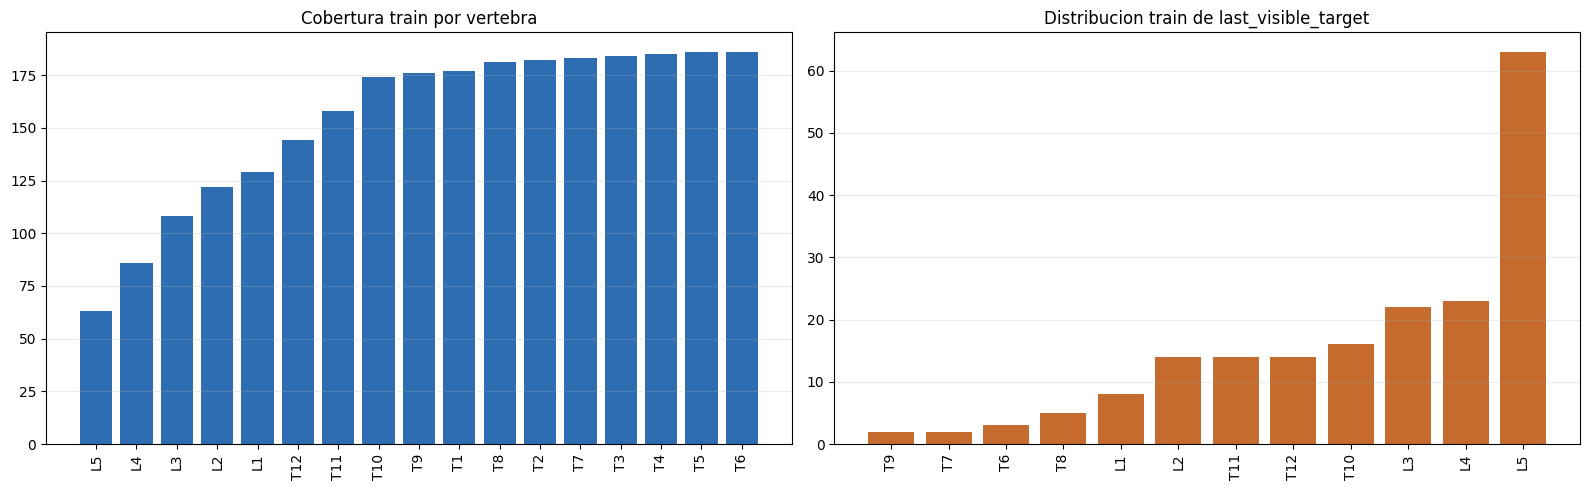

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    vertebra_presence_train_df['vertebra_label'],
    vertebra_presence_train_df['train_images_with_label'],
    color='#2f6db3'
)
axes[0].set_title('Cobertura train por vertebra')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(alpha=0.25, axis='y')

axes[1].bar(
    last_visible_distribution_df['last_visible_target'],
    last_visible_distribution_df['train_images'],
    color='#c46b2d'
)
axes[1].set_title('Distribucion train de last_visible_target')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

## 11. Exportacion de resultados

Estas salidas quedan listas para ser usadas por un notebook futuro de
reentrenamiento.

In [12]:
vertebra_presence_path = OUTPUT_DIR / 'vertebra_presence_train_imbalance.csv'
last_distribution_path = OUTPUT_DIR / 'last_visible_target_train_distribution.csv'
slice_summary_path = OUTPUT_DIR / 'last_visible_error_slice_summary.csv'
hard_cases_path = OUTPUT_DIR / 'hard_cases_last_visible_test.csv'
last_sampling_path = OUTPUT_DIR / 'train_sampling_weights_last_visible.csv'
multiclass_sampling_path = OUTPUT_DIR / 'train_sampling_weights_multiclass.csv'
recommendations_path = OUTPUT_DIR / 'refined_sampling_recommendations.csv'

vertebra_presence_train_df.to_csv(vertebra_presence_path, index=False)
last_visible_distribution_df.to_csv(last_distribution_path, index=False)
slice_summary_df.to_csv(slice_summary_path, index=False)
hard_case_df.to_csv(hard_cases_path, index=False)
last_sampling_weights_df.to_csv(last_sampling_path, index=False)
multiclass_sampling_weights_df.to_csv(multiclass_sampling_path, index=False)
recommendations_df.to_csv(recommendations_path, index=False)

print('Guardado:', vertebra_presence_path)
print('Guardado:', last_distribution_path)
print('Guardado:', slice_summary_path)
print('Guardado:', hard_cases_path)
print('Guardado:', last_sampling_path)
print('Guardado:', multiclass_sampling_path)
print('Guardado:', recommendations_path)

Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hard_case_mining_thoracolumbar_explained_tuned/vertebra_presence_train_imbalance.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hard_case_mining_thoracolumbar_explained_tuned/last_visible_target_train_distribution.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hard_case_mining_thoracolumbar_explained_tuned/last_visible_error_slice_summary.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hard_case_mining_thoracolumbar_explained_tuned/hard_cases_last_visible_test.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hard_case_mining_thoracolumbar_explained_tuned/train_sampling_weights_last_visible.csv
Guardado: /content/drive/Othercomputers/Mi portátil/Sc